## Nearest Neighbor Class Fidelity (cf) Metric Implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import RFE
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import MDS, TSNE
import umap
%matplotlib inline

ModuleNotFoundError: No module named 'umap'

## Nearest Neighbor Class Fidelity (cf) Metric
$\text{fidelity}_k$ - wiernosć klasowa dla $k$ sąsiadów

$k$ - aktualna liczba rozważanych sąsiadów

$K_{\text{max}}$ - maksymalna liczba sąsiadów (=100)

$\text{hits}_k (i)$ - liczba sąsiadów punktu $i$ z właściwej klasy

$N$ - całkowita liczba punktów danych

$$
$$

$$
\text{NNCF} = \frac{1}{K_{\text{max}}} \sum_{k=1}^{K_{\text{max}}} \text{fidelity}_k
$$

$$
\text{fidelity}_k = \frac{1}{k \cdot N} \sum_{i = 1}^{N} \text{hits}_k (i)
$$
gdzie $\text{hits}_k$ to liczba spośród $k$ najbliższych sąsiadów punktu $y_i$ (przestrzeń niskowymiarowa), które należą do tej samej klasy co $x_i$ (przestrzeń oryginalna).

In [10]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

class NearestNeighborClassFidelity:
    def __init__(self, X_low: np.ndarray, y: np.array, k_max: int = 100):
        self.X_low = X_low
        self.y = y
        self.k_max = k_max

        # +1 because kneighbors includes the point itself when querying training data
        self.knn_low = NearestNeighbors().fit(X_low)
    #

    def fidelity_k(self, k: int) -> float:
        n = len(self.y)

        # Find k+1 neighbors (index 0 is the point itself - will be excluded)
        _, neighbor_indices = self.knn_low.kneighbors(self.X_low, n_neighbors=k + 1)
        neighbor_indices = neighbor_indices[:, 1:]  # shape: (n, k) - drop self

        # For each point i, get classes of its k neighbors
        neighbor_classes = self.y[neighbor_indices]       # shape: (n, k)
        own_classes = self.y.reshape(-1, 1)               # shape: (n, 1)

        # hits_k(i) = number of neighbors with the same class
        hits = np.sum(neighbor_classes == own_classes, axis=1)  # shape: (n,)

        return hits.sum() / (k * n)

    def compute(self) -> float:
        fidelity_scores = [self.fidelity_k(k) for k in range(1, self.k_max + 1)]
        return float(np.mean(fidelity_scores))
#

## MNIST with NNCF

### PCA

In [11]:
import mnists
mnist = mnists.MNIST()

NUM_OF_SAMPLES=12*24*3

digits = mnist.train_images()[:NUM_OF_SAMPLES]
digits = digits.reshape(digits.shape[0], -1)

X = digits / 255
y = mnist.train_labels()[:NUM_OF_SAMPLES]

In [12]:
def scatter_2d(X, y):
    X = np.asarray(X)
    y = np.asarray(y)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap='tab10',
        s=10,
        alpha=0.7
    )

    plt.colorbar(scatter)
    plt.show()
#

In [13]:
def plot_2d(x, y, xlabel="x", ylabel="y", title="") -> None:
    plt.figure(figsize=(8, 6))
    plt.plot(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()
#

0.3567270772419135


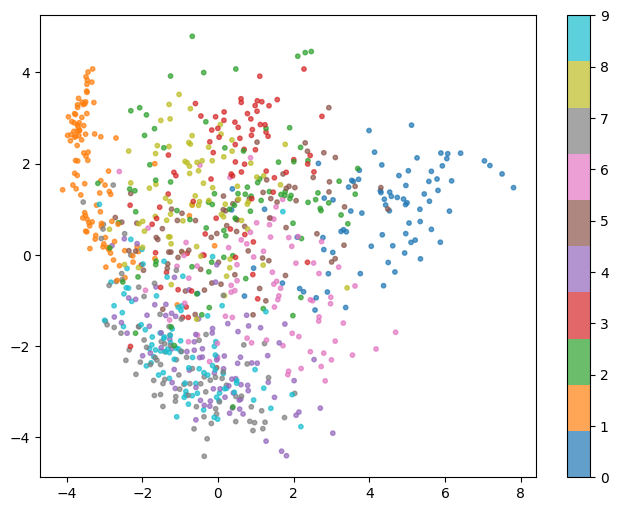

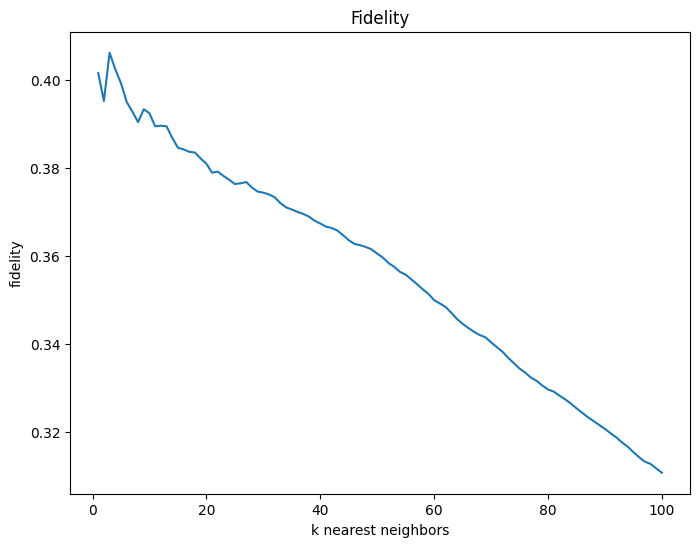

In [14]:
pca = PCA(n_components=2)
mnist_reduced_pca_two_dim = pca.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_pca_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_pca_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)

0.35641851665276314


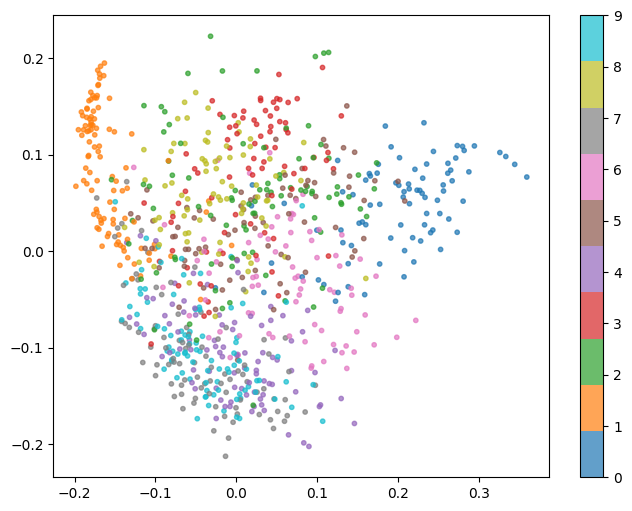

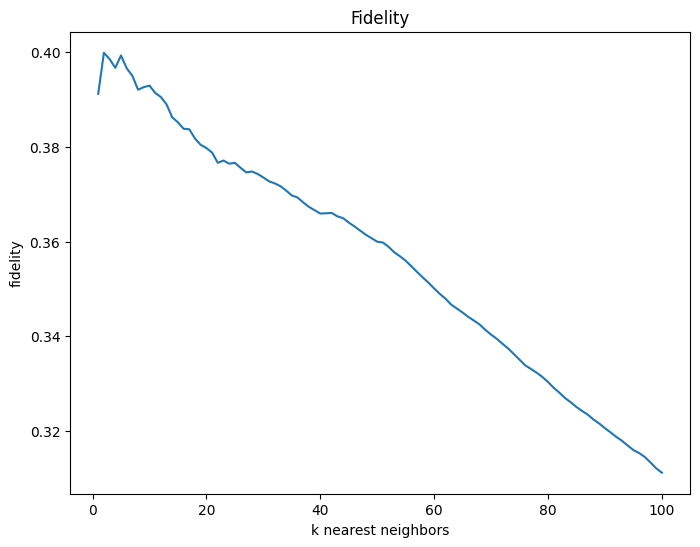

In [15]:
kernel_pca = KernelPCA(
    kernel='rbf',
    n_components=2
)
mnist_reduced_kernel_pca_two_dim = kernel_pca.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_kernel_pca_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_kernel_pca_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)

## t-SNE

0.6210231000628122


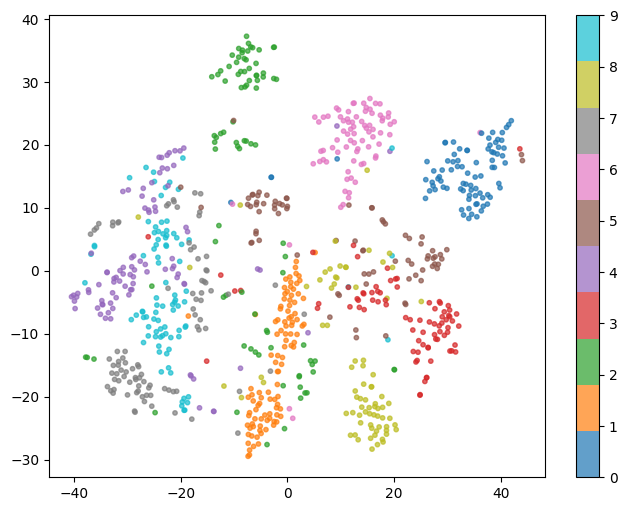

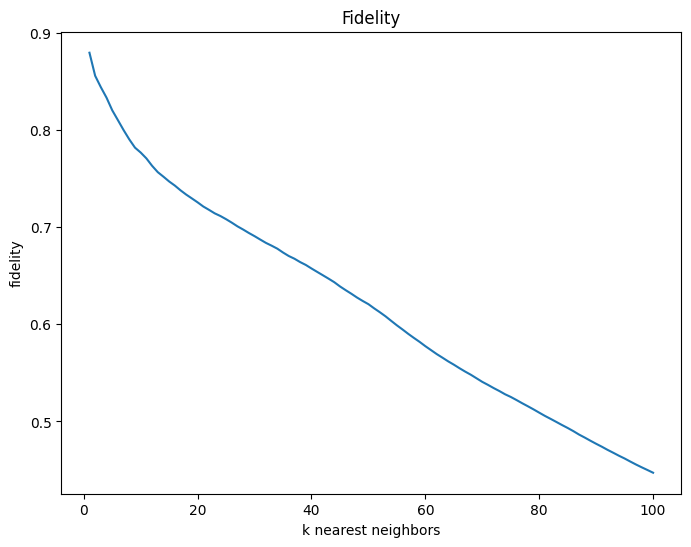

In [17]:
tsne = TSNE(n_components=2, perplexity=30)
mnist_reduced_tsne_two_dim = tsne.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_tsne_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_tsne_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)